# Plot annual FSNS (flux, SW, net, surface) and FSNSC (flux, SW, net, surface, clear-sky) globally

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
from scipy import stats

In [2]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
    """Swaps longitude coordinates from range (0, 360) to (-180, 180)
    Args:
        dataset (xr.Dataset): xarray Dataset
    Returns:
        xr.Dataset: xarray Dataset with swapped longitude dimensions
    """
    lon_name = "lon"  # whatever name is in the data

    # Adjust lon values to make sure they are within (-180, 180)
    dataset["_longitude_adjusted"] = xr.where(
        dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
    dataset = (
        dataset.swap_dims({lon_name: "_longitude_adjusted"})
        .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
        .drop_vars(lon_name)
    )

    dataset = dataset.rename({"_longitude_adjusted": lon_name})
    return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ARISE_ens = []
    SSP245_ens = []

    for ens_num in range(1, 11):
        ARISE_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_ARISE_{ens_num:02d}_203501-206912.nc"))
        SSP245_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_SSP245_{ens_num:02d}_202001-206912.nc"))

    arise_da = xr.concat(ARISE_ens, dim=xr.DataArray(np.arange(1, len(ARISE_ens)+1), dims="ensemble", name="ensemble"))
    ssp245_da = xr.concat(SSP245_ens, dim=xr.DataArray(np.arange(1, len(SSP245_ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        arise_da = land_filter(arise_da)
        ssp245_da = land_filter(ssp245_da)

    return arise_da, ssp245_da

## Load and process data

In [6]:
# === Path config ===
BASE_DIR = "/glade/work/awells/air_quality/CESM/radiation/"
SCENARIOS = ["ARISE", "SSP245"]


# === Main loop ===
arise_fsns, ssp245_fsns = merge_ensembles(f"{BASE_DIR}FSNS/", "FSNS", land_mask=True)
arise_fsnsc, ssp245_fsnsc = merge_ensembles(f"{BASE_DIR}FSNSC/", "FSNSC", land_mask=True)

Filtering ocean
Filtering ocean


## Calculate statistical significance

In [7]:
# === Stats functions ===
def process_da_for_stats(da, start_year, end_year):
    da_r = da.sel(time=slice(start_year, end_year)).sel(ensemble=1)
    for i in range(2, len(da.ensemble)+1):
        da_ens = da.sel(time=slice(start_year, end_year)).sel(ensemble=i)
        da_r = xr.concat((da_r, da_ens), dim="time")
    return da_r


def stat_sig(da1, da2):
    # For latitude, longitude plots
    stat, pval = stats.ttest_ind(da1, da2)
    pval_da = xr.DataArray(data=pval,
                           dims=["lat", "lon"],
                           coords=dict(lon=(["lon"], da1.lon.values),
                                       lat=(["lat"], da1.lat.values)))
    return pval_da

In [8]:
ssp245_late_r = process_da_for_stats(ssp245_fsns, "2050", "2069")
arise_r = process_da_for_stats(arise_fsns, "2050", "2069")

ssp245_late_rc = process_da_for_stats(ssp245_fsnsc, "2050", "2069")
arise_rc = process_da_for_stats(arise_fsnsc, "2050", "2069")

In [16]:
arise_late_pval = adjust_longitude(stat_sig(arise_r, ssp245_late_r))

arise_late_pval_c = adjust_longitude(stat_sig(arise_rc, ssp245_late_rc))

In [13]:
arise = arise_fsns.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))
ssp245_late = ssp245_fsns.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))

arise_c = arise_fsnsc.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))
ssp245_late_c = ssp245_fsnsc.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))

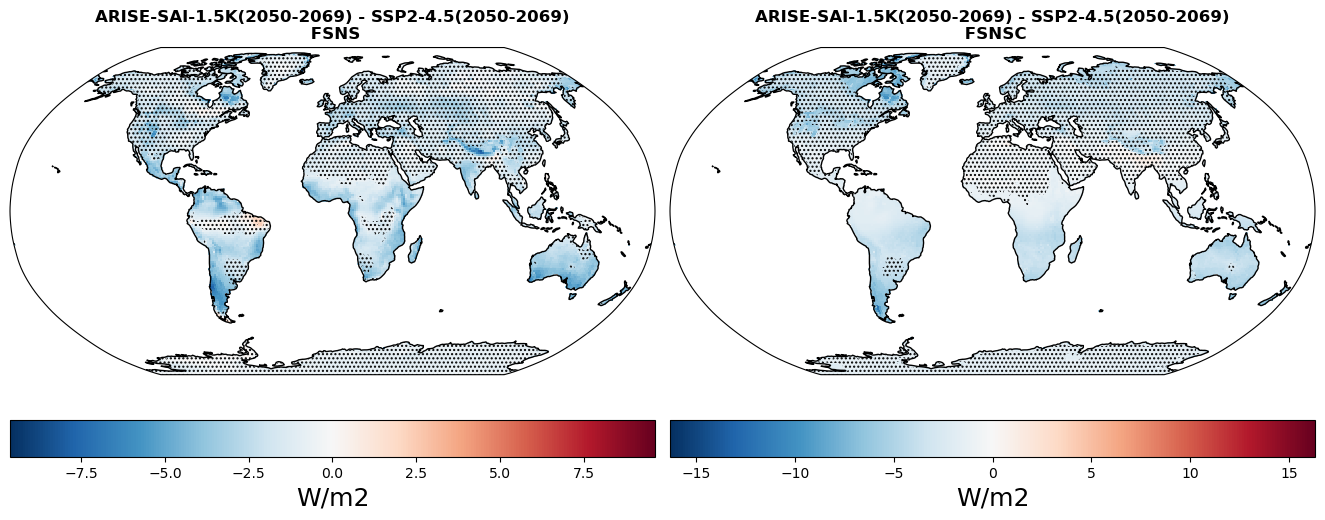

In [17]:
fig = plt.figure(figsize=autosize_figure(1, 2))
gs = GridSpec(2, 2, height_ratios=[15, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('BrBG')

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_late).plot(transform=crs, add_colorbar=False,
                                subplot_kws={'projection': projection})
arise_late_pval.where(arise_late_pval > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['....'], add_colorbar=False)
ax.coastlines()
plt.title('ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)\n FSNS', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[1, 0])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('W/m2', fontsize=18)

# First panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = (arise_c - ssp245_late_c).plot(transform=crs, add_colorbar=False,
                                subplot_kws={'projection': projection})
arise_late_pval_c.where(arise_late_pval_c > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['....'], add_colorbar=False)
ax.coastlines()
plt.title('ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)\n FSNSC', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[1, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('W/m2', fontsize=18)

plt.tight_layout()


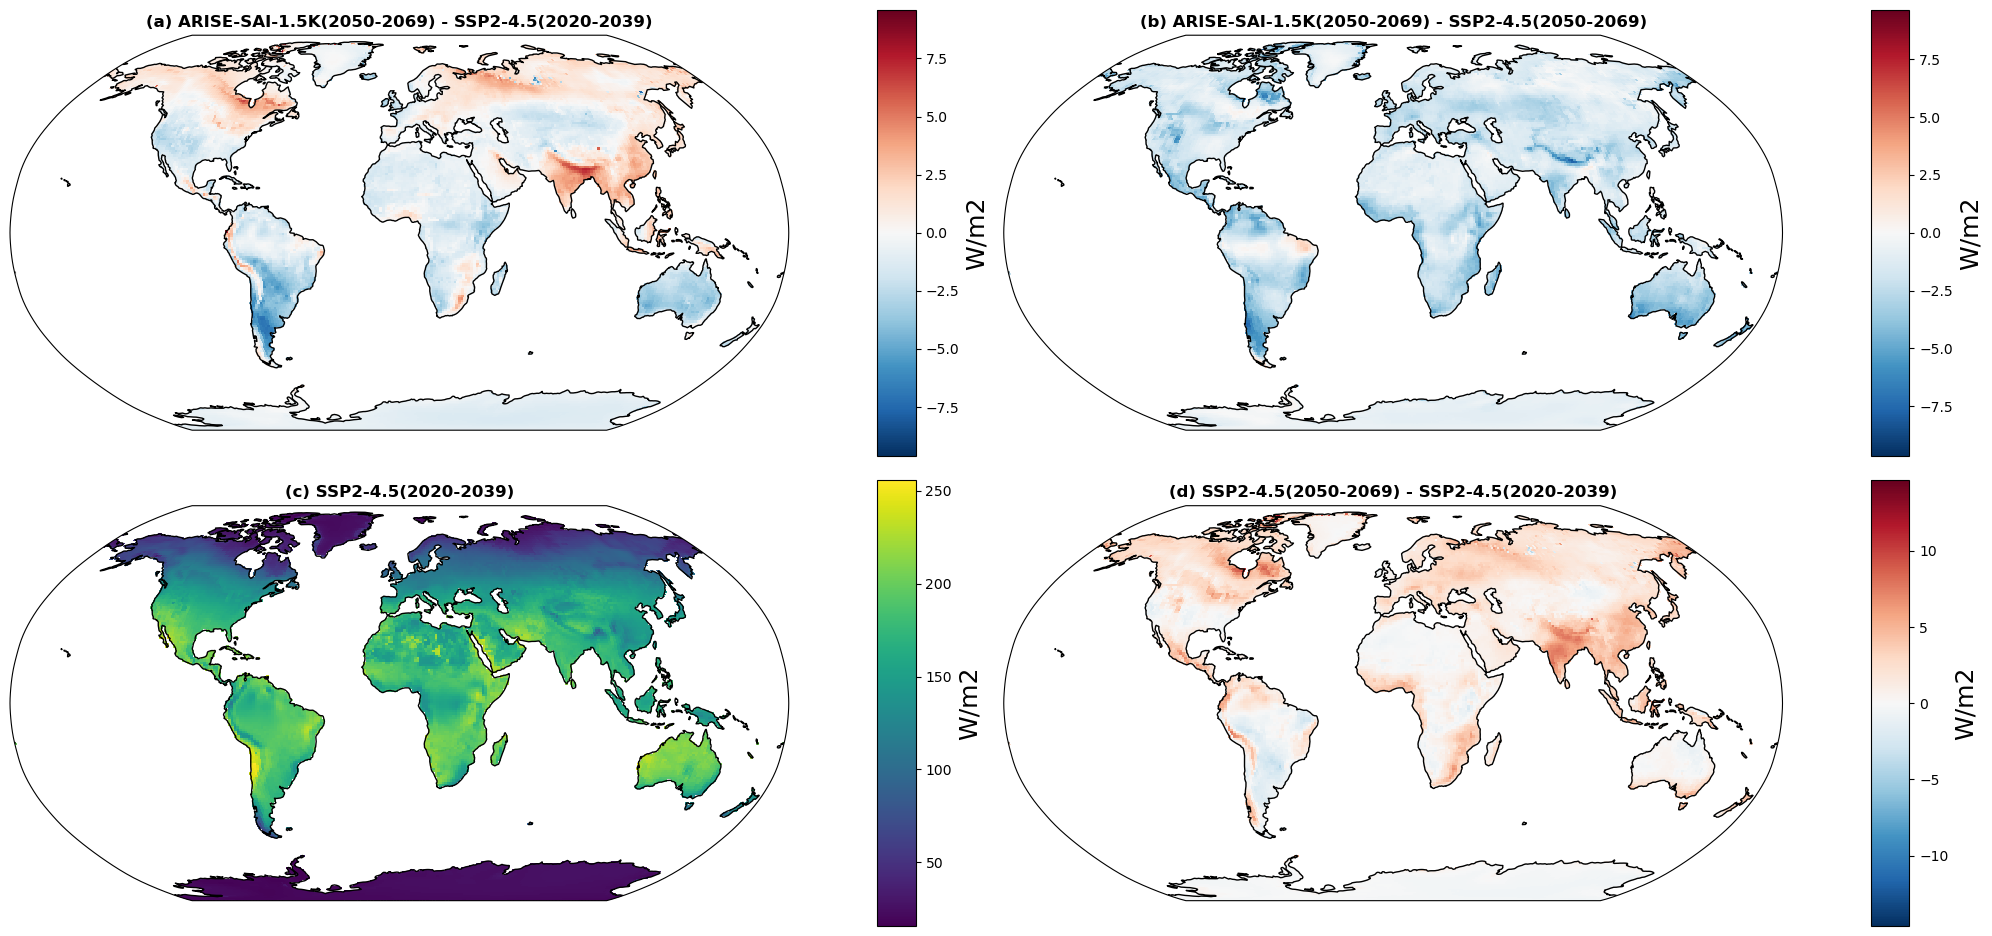

In [19]:
fig = plt.figure(figsize=autosize_figure(2, 2, xscale_factor=1.5))
gs = GridSpec(2, 4, width_ratios=[20, 1, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('BrBG')

arise = arise_fsns.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))
ssp245_early = ssp245_fsns.sel(time=slice("2020", "2039")).mean(dim=("ensemble", "time"))
ssp245_late = ssp245_fsns.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_early).plot(transform=crs, add_colorbar=False,
                         subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(a) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[0, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('W/m2', fontsize=18)

# Second panel
ax = fig.add_subplot(gs[0, 2], projection=projection, frameon=True)
cb = (arise - ssp245_late).plot(transform=crs, add_colorbar=False,
                          subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(b) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)', fontweight='bold')

# Second colorbar
cax = fig.add_subplot(gs[0, 3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('W/m2', fontsize=18)

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = (ssp245_early).plot(transform=crs, add_colorbar=False,
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(c) SSP2-4.5(2020-2039)', fontweight='bold')

# Third colorbar
cax = fig.add_subplot(gs[1, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('W/m2', fontsize=18)

# Fourth panel
ax = fig.add_subplot(gs[1, 2], projection=projection, frameon=True)
cb = (ssp245_late - ssp245_early).plot(transform=crs, add_colorbar=False,
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(d) SSP2-4.5(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# Fourth colorbar
cax = fig.add_subplot(gs[1,3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('W/m2', fontsize=18)

plt.tight_layout()
